In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

In [2]:
out_dir = '.'
devices = ['cpu', 'gpu_b200']

# Load the qutip data

In [3]:
ref_runs = np.load(f'{out_dir}/ref.npy', allow_pickle=True).item()['ref']
dims = np.array([5,10,20,40,80,160])

In [4]:
# #### 
# # Optional: remove the stored quasienergies and Floquet modes, to save space

# ref_runs_copy = ref_runs.copy()
# for dim in ref_runs_copy.keys():
#     for run_idx, _ in enumerate(ref_runs_copy[dim]):
#         _ = ref_runs_copy[dim][run_idx].pop('q', None)
#         _ = ref_runs_copy[dim][run_idx].pop('m', None)

# np.save('ref_cp.npy', {'ref' : ref_runs_copy})

# Plot all the other data

In [5]:
def collect(runs_by_dim, key):
    """Return (valid_dims, medians, all_values) skipping dims with no data."""
    valid_dims, medians, all_values = [], [], []
    for d in dims:
        if d not in runs_by_dim:
            continue
        vals = [row[key] for row in runs_by_dim[d]]
        valid_dims.append(d)
        medians.append(np.median(vals))
        all_values.append(vals)
    return np.array(valid_dims), medians, all_values

def any_row_has_key(runs_by_method, key):
    return any(
        key in row
        for runs_by_dim in runs_by_method.values()
        for rows in runs_by_dim.values()
        for row in rows
    )

def plot_series(ax, d_arr, medians, all_values, marker, label, color, linestyle='-', alpha=1):
    if len(d_arr) == 0:
        return
    line, = ax.plot(d_arr, medians, marker=marker, linestyle=linestyle, label=label, 
                    color=color, alpha=alpha)
    for d, vals in zip(d_arr, all_values):
        ax.scatter([d] * len(vals), vals, marker=marker, color=color, alpha=0.25, s=15, zorder=3)

def style_axis(ax, dims, title, ylabel, fontsize):
    ax.set_xlabel('Dimension $d$', fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xticks(dims)
    ax.set_xticklabels(dims, rotation=45, ha='right')
    ax.tick_params(axis='both', labelsize=fontsize)
    ax.set_title(title, fontsize=fontsize)

def plot_nonbasic(data, dims, ref_runs, suptitle="", w=6, h=(3/4)*6, fontsize=12):

    methods = [
        ('ref', 'o', 'blue', '-', 'QuTiP reference'),
    ]
    for idx, (polar, diag, frame) in enumerate(
        product(['', 'polar'], ['basic', 'cayley'], ['lab', 'ip'])
    ):  
        methods.append((
            f'{frame}_{diag}' + (f'_{polar}' if polar else ''), # name
            ['s', '^', '1', 'P', 'D', '*', 'X', 'p'][idx], # marker
            ['orange', 'green', 'red', 'purple'][idx%4], # color
            ['-', '--'][idx//4], # line style
            f'{frame.capitalize()} | {diag.capitalize()}' + (
                f'| {polar.capitalize()}' if polar else ''
            ) # label
        ))
    runs_by_method = {'ref': ref_runs}
    runs_by_method |= {method_name : data[method_name] for method_name, *_ in methods[1:]}

    has_gpu_mem = any_row_has_key(runs_by_method, 'mem_gpu')

    fig1, axs1 = plt.subplots(1, 3, figsize=(3*w, h),   constrained_layout=True, sharex=True)
    fig2, axs2 = plt.subplots(2, 3, figsize=(3*w, 2*h), constrained_layout=True, sharex=True)
    axs = np.concatenate([axs1, axs2.flatten()])

    panels = [
        (axs[0], 't_total',   methods    , 'Time (s)', 'Wall time vs. dimension', 'log'),
        (axs[1], 'mem_total', methods    , 'Memory Host (MB)', 'Memory Host vs. dimension', 'log'),
        None, # GPU plot, see below
        (axs[3], 'qerr'     , methods[1:], 'Max quasienergy difference', 'Quasienergy error vs. dimension', 'log'),
        (axs[4], 'merr', methods[1:], 'Max Floquet mode component difference', 'Floquet mode error vs. dimension', 'log'),
        (axs[5], 'nonunit_max', methods, r'Max component of $|U^\dagger U - I|$ ', 'Non-unitarity of final propagator', 'log'),
        (axs[6], 'h0_norm', methods, r'Spectral norm of $H_0$', 'Spectral norm of $H_0$', 'log'),
        (axs[7], 'T', methods, r'Period $T$', 'Period $T$', 'log'),
        (axs[8], 'h0_normT', methods, r', $||H_0|| T$', 'Phase accumulation rate', 'log')
    ]
    if has_gpu_mem:
        panels[2] = (axs[2], 'mem_gpu', methods[1:], 'Memory GPU (MB)', 'Memory GPU vs. dimension', 'log')
    else:
        panels[2] = (axs[2], None, None, None, None, None)

    for idx, (ax, key, ms, ylabel, title, yscale) in enumerate(panels):
        if key is None:
            continue
        for mkey, marker, color, linestyle, label in ms:
            plot_series(ax, *collect(runs_by_method[mkey], key), 
                        marker=marker, color=color, label=label, linestyle=linestyle)
        style_axis(ax, dims, title, ylabel, fontsize)
        ax.set_yscale(yscale)

        if idx in [3,4,5]:
            ax.set_xlabel(None)

    # All subplots share the same method legend; show it once to the right of the figure.
    handles, labels = [], []
    for ax in axs:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h)
                labels.append(l)
    fig1.legend(handles, labels, loc='outside right center', fontsize=fontsize)
    fig2.legend(handles, labels, loc='outside right center', fontsize=fontsize)

    if suptitle:
        fig1.suptitle(suptitle, fontsize=1.5*fontsize)
        fig2.suptitle(suptitle, fontsize=1.5*fontsize)
    
    plt.show()

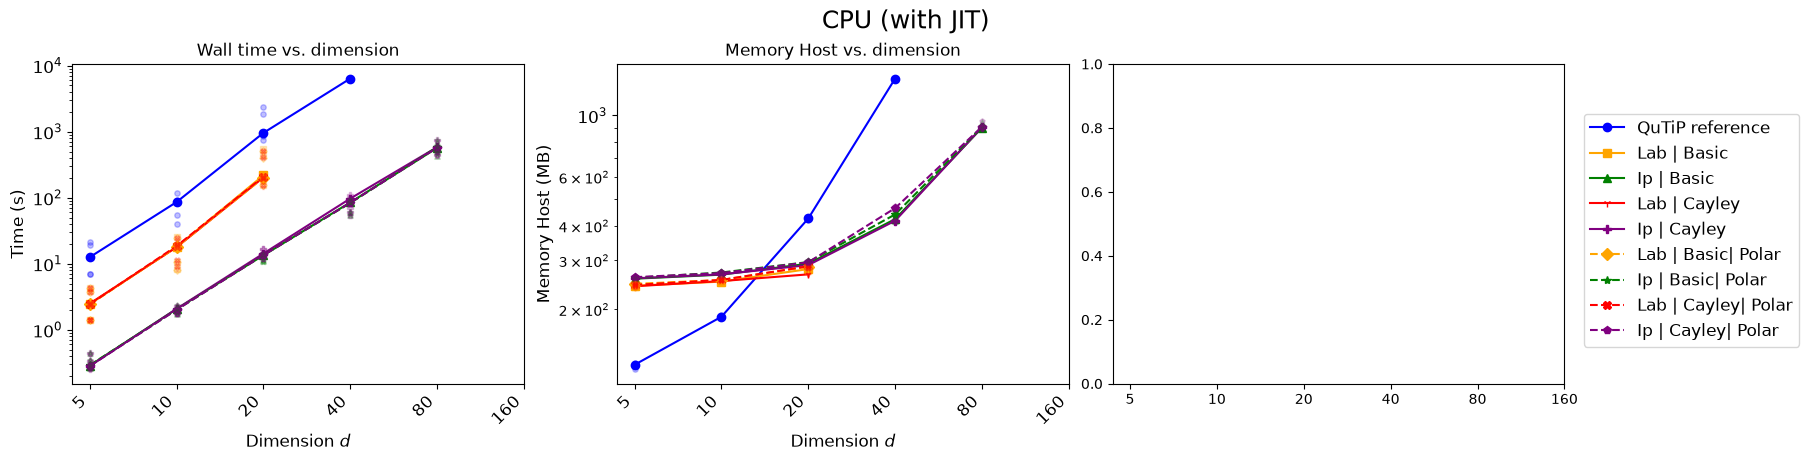

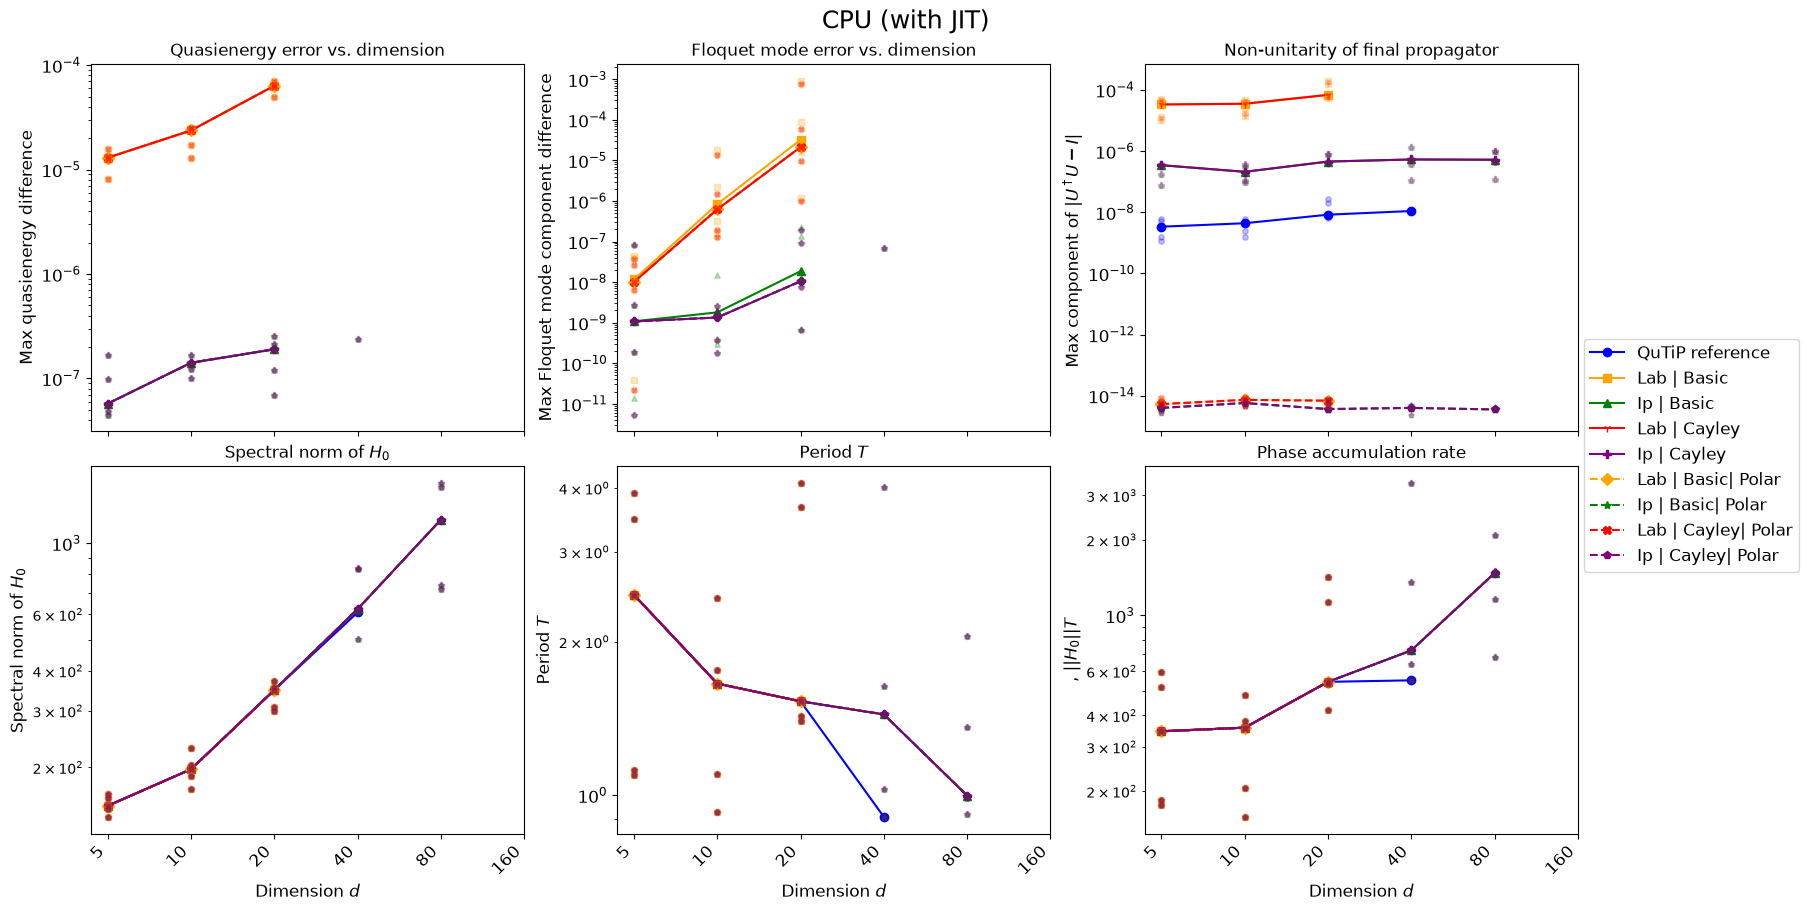

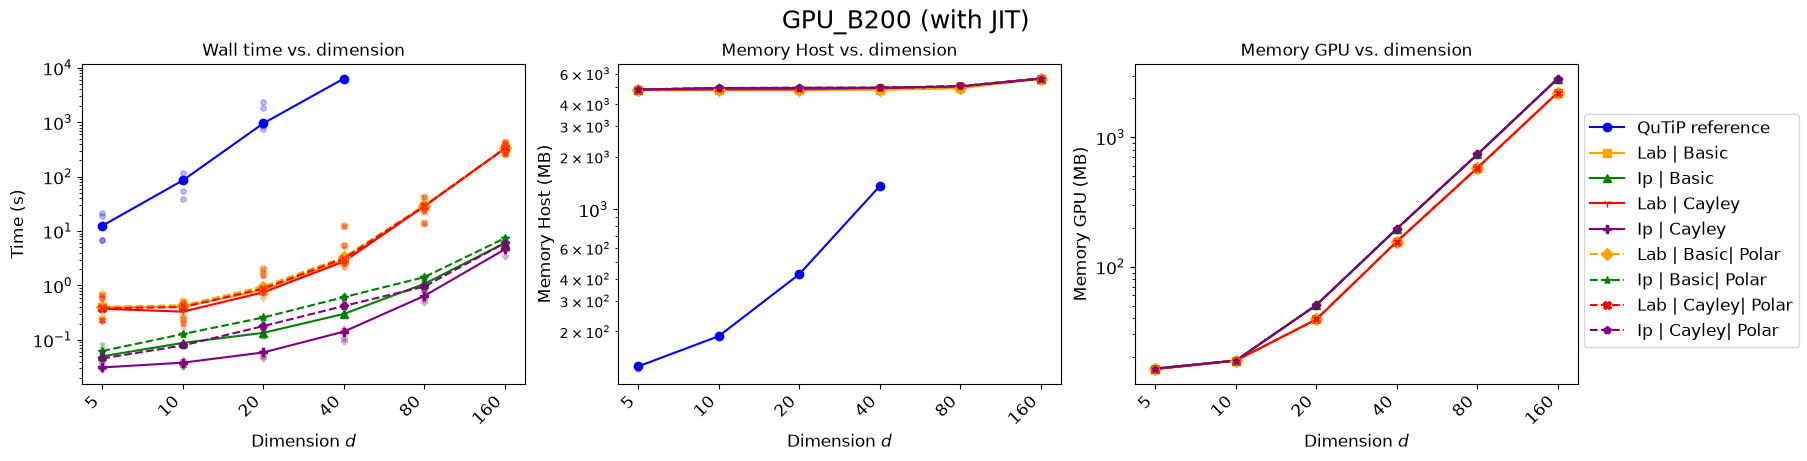

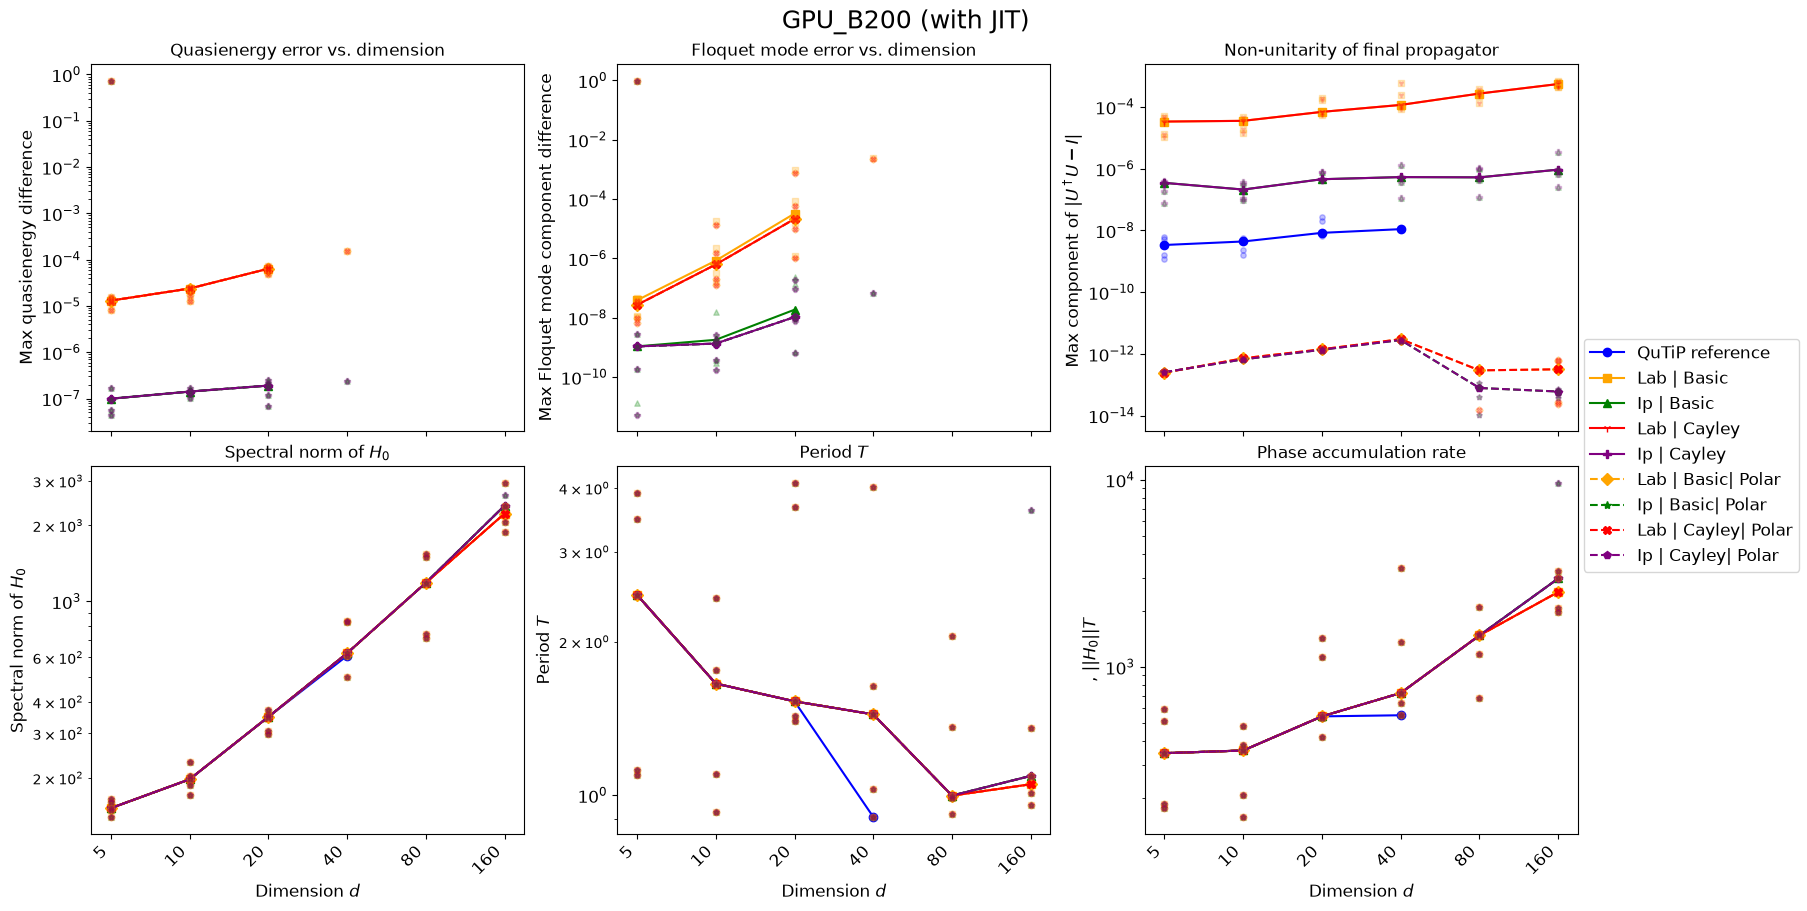

In [6]:
for device in devices:
    for jit in [True]:
        data = np.load(f'{out_dir}/{device}.npy', allow_pickle=True).item()
        plot_nonbasic(data, dims, ref_runs, 
                      suptitle=f'{device.upper()} ({"with" if jit else "without"} JIT)')

# Blaming $\|H_0\|_2 T$ for the non-unitarity

Plotting non-unitarity against dimension cannot separate the two candidate causes:
$\|H_0\|_2$ and the Hilbert dimension are collinear by construction
($\|H_0\| \approx \omega_r d$), at `corr = +0.98` in log-log.

The randomized $\omega_d$ is what breaks the tie. $T = 2\pi/\omega_d$ is drawn
independently of $d$, so $\|H_0\|_2 T$ still spans 3-6x **at fixed dimension**.
Plotting against $\|H_0\|_2 T$ instead of $d$ therefore lets every dimension
fall on one common line if the phase is the true driver.

**Left**: by solver, with a slope-1 guide. **Right**: lab frame only, coloured by
dimension -- if the colours collapse onto the guide line, dimension is just a label
scattered along a single $\|H_0\|_2 T$ curve.

In [13]:
def flatten(runs_by_dim, xkey='h0_normT', ykey='nonunit_max'):
    """Flatten {dim: [row, ...]} into (x, y, dim) arrays, one point per run."""
    x, y, dd = [], [], []
    for dim, rows in runs_by_dim.items():
        for row in rows:
            x.append(row[xkey]); y.append(row[ykey]); dd.append(dim)
    x, y, dd = np.array(x), np.array(y), np.array(dd)
    ok = np.isfinite(x) & np.isfinite(y) & (y > 0)
    return x[ok], y[ok], dd[ok]

def slope_one_guide(ax, x, y, fontsize, label=True):
    """Dashed line of slope 1 through the median of (x, y): y = C * x."""
    C = np.median(y / x)
    xs = np.array([x.min() * 0.7, x.max() * 1.4])
    ax.plot(xs, C * xs, ls='--', color='black', lw=1.2, zorder=1,
            label=f'slope 1  ($y = {C/1e-8:.0f}\\,\\|H_0\\|T \\times$ tol)' if label else None)
    return C

def style_phase_axis(ax, title, ylabel, fontsize):
    ax.set_xlabel(r'$\|H_0\|_2\, T$  (rad)', fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.tick_params(axis='both', labelsize=fontsize)
    ax.set_title(title, fontsize=fontsize)

def plot_nonunit_vs_phase(data, basic_runs, jit=True, suptitle='', fontsize=12):
    methods = [
        ('ref', 'o', 'blue', '-', 'QuTiP reference'),
    ]
    for idx, (polar, diag, frame) in enumerate(
        product(['', 'polar'], ['basic', 'cayley'], ['lab'])
    ):  
        methods.append((
            f'{frame}_{diag}' + (f'_{polar}' if polar else ''), # name
            ['s', '^', '1', 'P', 'D', '*', 'X', 'p'][idx], # marker
            ['orange', 'green', 'red', 'purple'][idx%4], # color
            ['-', '--'][idx//4], # line style
            f'{frame.capitalize()} | {diag.capitalize()}' + (
                f'| {polar.capitalize()}' if polar else ''
            ) # label
        ))
    runs_by_method = {'ref': ref_runs}
    runs_by_method |= {method_name : data[method_name] for method_name, *_ in methods[1:]}

    fig, axs = plt.subplots(1, 2, figsize=(6*2, (3/4)*6), constrained_layout=True)

    # All solvers
    for mkey, marker, color, _, label in methods:
        x, y, _ = flatten(runs_by_method[mkey])
        axs[0].scatter(x, y, marker=marker, color=color, label=label, alpha=0.6, s=30)

    xl = np.concatenate([flatten(runs_by_method[m])[0] for m, *_ in methods])
    yl = np.concatenate([flatten(runs_by_method[m])[1] for m, *_ in methods])
    C = slope_one_guide(axs[0], xl, yl, fontsize)
    style_phase_axis(axs[0], 'Non-unitarity vs. accumulated phase',
                     r'Max component of $|U^\dagger U - I|$', fontsize)
    axs[0].legend(fontsize=0.85*fontsize)

    # Only lab frame, seperate by dims
    all_dims = sorted({d for m, *_ in methods for d in runs_by_method[m]})
    cmap = plt.cm.viridis(np.linspace(0, 0.9, len(all_dims)))
    for color, dim in zip(cmap, all_dims):
        xs, ys = [], []
        for mkey, *_ in methods:
            if dim in runs_by_method[mkey]:
                x, y, _ = flatten({dim: runs_by_method[mkey][dim]})
                xs.append(x); ys.append(y)
        if not xs:
            continue
        axs[1].scatter(np.concatenate(xs), np.concatenate(ys),
                       color=color, label=f'$d$ = {dim}', alpha=0.8, s=30)
    slope_one_guide(axs[1], xl, yl, fontsize, label=False)
    style_phase_axis(axs[1], 'Lab frame only, coloured by dimension',
                     r'Max component of $|U^\dagger U - I|$', fontsize)
    axs[1].legend(fontsize=0.85*fontsize, ncol=2)

    if suptitle:
        fig.suptitle(suptitle, fontsize=1.5*fontsize)
    plt.show()

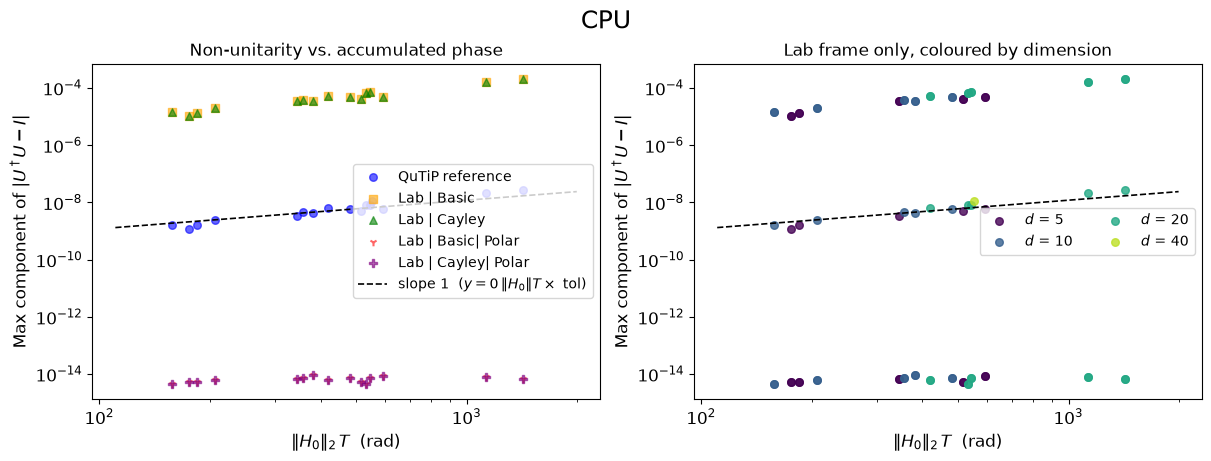

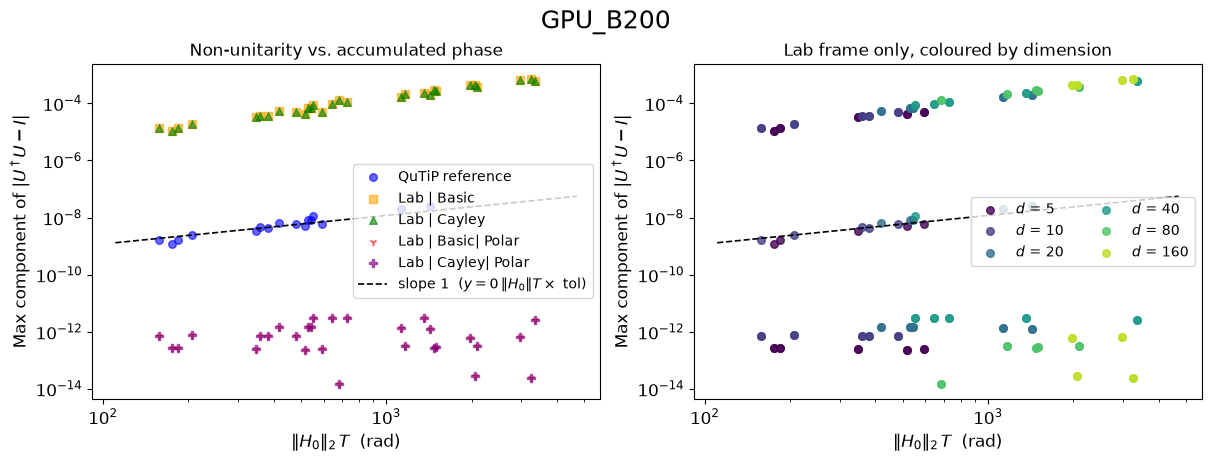

In [14]:
for device in devices:
    data = np.load(f'{out_dir}/{device}.npy', allow_pickle=True).item()
    plot_nonunit_vs_phase(data, ref_runs, jit=True, suptitle=f'{device.upper()}')